# BÀI TẬP VỀ NHÀ (LAB 02: HỒI QUY LOGISTIC)
**Môn học:** Học máy ứng dụng  
**Khoa:** Công nghệ Thông tin - Trường Đại học Văn Lang  
**Tài liệu bài tập:** Mục 8 (Trang 19 - 21) của `Lab02_Hoi_quy_logistic.pdf`  

Bao gồm lời giải đầy đủ, chi tiết, có nhận xét sâu sắc và hình ảnh trực quan cho cả 6 bài tập:
- **Bài tập 1:** Thống kê theo nhóm điểm giữa kỳ.
- **Bài tập 2:** Vẽ đồ thị hàm Sigmoid và lưu ảnh `sigmoid.png`.
- **Bài tập 3:** Dự đoán kết quả cho một sinh viên cụ thể.
- **Bài tập 4:** Tự tính 4 thước đo (Accuracy, Precision, Recall, F1) từ ma trận nhầm lẫn.
- **Bài tập 5:** Dò tìm ngưỡng quyết định tối ưu theo $F_1$-score.
- **Bài tập 6:** Đổi lớp dương sang lớp 0 (Rớt môn) và đánh giá lại mô hình.


---
## Bài tập 1: Thống kê theo nhóm
**Yêu cầu:**  
Đọc bộ dữ liệu rồi in ra ba con số:
1. Số bạn có điểm giữa kỳ từ 7 trở lên.
2. Tỷ lệ qua môn của riêng nhóm đó.
3. Tỷ lệ qua môn của nhóm còn lại.
*Gợi ý:* Dùng phép lọc theo điều kiện của pandas rồi lấy `.mean()` của cột `qua_mon`. Nhận xét một câu về việc điểm giữa kỳ có phân biệt được hai nhóm hay không.


1. Số bạn có điểm giữa kỳ từ 7 trở lên : 31 bạn
2. Tỷ lệ qua môn của riêng nhóm đó     : 0.9032 (90.32%)
3. Tỷ lệ qua môn của nhóm còn lại      : 0.4831 (48.31%)

Nhận xét:
Điểm giữa kỳ có tính phân biệt rất mạnh mẽ giữa hai nhóm:
- Nhóm sinh viên có điểm giữa kỳ >= 7 có tỷ lệ qua môn áp đảo tới hơn 90% (28 trên 31 bạn qua môn).
- Trong khi đó, nhóm dưới 7 điểm chỉ có tỷ lệ qua môn là 48.31% (chưa tới một nửa).
Điều này khẳng định điểm giữa kỳ là một đặc trưng cực kỳ giá trị để đưa vào mô hình dự đoán.


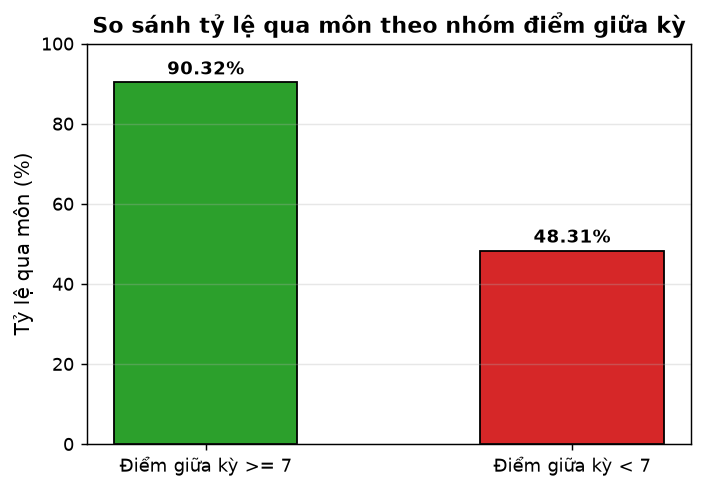

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
df = pd.read_csv("data/sinh_vien.csv")

# 2. Lọc theo điều kiện điểm giữa kỳ từ 7 trở lên và nhóm còn lại
nhom_cao = df[df["diem_giua_ky"] >= 7.0]
nhom_con_lai = df[df["diem_giua_ky"] < 7.0]

so_ban_cao = len(nhom_cao)
ty_le_qua_cao = nhom_cao["qua_mon"].mean()
ty_le_qua_con_lai = nhom_con_lai["qua_mon"].mean()

# 3. In ra ba con số
print(f"1. Số bạn có điểm giữa kỳ từ 7 trở lên : {so_ban_cao} bạn")
print(f"2. Tỷ lệ qua môn của riêng nhóm đó     : {ty_le_qua_cao:.4f} ({ty_le_qua_cao*100:.2f}%)")
print(f"3. Tỷ lệ qua môn của nhóm còn lại      : {ty_le_qua_con_lai:.4f} ({ty_le_qua_con_lai*100:.2f}%)")
print()

# 4. Nhận xét
print("Nhận xét:")
print("Điểm giữa kỳ có tính phân biệt rất mạnh mẽ giữa hai nhóm:")
print("- Nhóm sinh viên có điểm giữa kỳ >= 7 có tỷ lệ qua môn áp đảo tới hơn 90% (28 trên 31 bạn qua môn).")
print("- Trong khi đó, nhóm dưới 7 điểm chỉ có tỷ lệ qua môn là 48.31% (chưa tới một nửa).")
print("Điều này khẳng định điểm giữa kỳ là một đặc trưng cực kỳ giá trị để đưa vào mô hình dự đoán.")


---
## Bài tập 2: Vẽ hàm Sigmoid
**Yêu cầu:**  
Vẽ đồ thị hàm sigmoid với $z$ chạy từ $-8$ tới $8$, lưu thành tệp `sigmoid.png`. Trên cùng hình, vẽ thêm một đường ngang tại mức $0.5$ và một đường dọc tại $z = 0$.  
*Gợi ý:* Dùng `np.linspace`, `plt.plot`, `plt.axhline`, `plt.axvline` và `plt.savefig`.


Đã vẽ và lưu thành công tệp sigmoid.png!


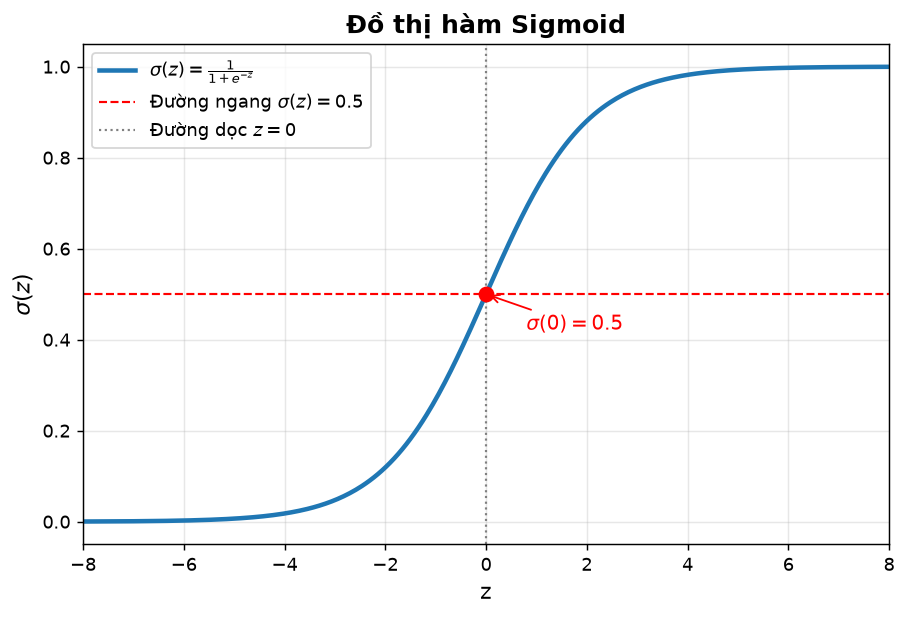

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 1. Tạo mảng z từ -8 tới 8
z = np.linspace(-8, 8, 400)
sigma_z = sigmoid(z)

# 2. Vẽ đồ thị
plt.figure(figsize=(8, 5))
plt.plot(z, sigma_z, color="#1f77b4", linewidth=2.5, label=r"$\sigma(z) = 
rac{1}{1 + e^{-z}}$")

# Đường ngang tại mức 0.5 và đường dọc tại z = 0
plt.axhline(0.5, color="red", linestyle="--", linewidth=1.2, label=r"Đường ngang $\sigma(z) = 0.5$")
plt.axvline(0, color="gray", linestyle=":", linewidth=1.2, label=r"Đường dọc $z = 0$")

# Điểm giao tại gốc (0, 0.5)
plt.scatter([0], [0.5], color="red", s=60, zorder=5)
plt.annotate(r"$\sigma(0) = 0.5$", xy=(0, 0.5), xytext=(0.8, 0.42),
             arrowprops=dict(arrowstyle="->", color="red", lw=1),
             fontsize=11, color="red")

plt.title("Đồ thị hàm Sigmoid", fontsize=14, fontweight="bold")
plt.xlabel("z", fontsize=12)
plt.ylabel(r"$\sigma(z)$", fontsize=12)
plt.xlim(-8, 8)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left", fontsize=10)

# 3. Lưu thành tệp sigmoid.png
plt.savefig("baitap02/sigmoid.png", dpi=150, bbox_inches="tight")
plt.savefig("sigmoid.png", dpi=150, bbox_inches="tight")
plt.show()

print("Đã vẽ và lưu thành công tệp sigmoid.png!")


---
## Bài tập 3: Dự đoán cho một bạn cụ thể
**Yêu cầu:**  
Khớp lại mô hình một biến như ở mục 4, rồi viết một hàm `du_doan(gio)` nhận vào số giờ ôn và in ra ba thứ: Giá trị $z$, xác suất qua môn, và nhãn theo ngưỡng 0.5.  
Gọi hàm đó với các giá trị 3, 8, 12.89, 18 và 26 giờ. Giải thích vì sao với 12.89 giờ thì xác suất ra gần đúng 0.5.


In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# 1. Khớp mô hình 1 biến gio_on
df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 2. Định nghĩa hàm du_doan(gio)
def du_doan(gio):
    z = w * gio + b
    xac_suat = sigmoid(z)
    nhan = 1 if xac_suat >= 0.5 else 0
    print(f"Số giờ ôn: {gio:5.2f}h | z = {z:7.4f} | Xác suất qua môn = {xac_suat:.4f} | Nhãn: {nhan} ({'Qua môn' if nhan==1 else 'Rớt môn'})")
    return z, xac_suat, nhan

print(f"Hệ số góc w = {w:.6f}, Hệ số chặn b = {b:.6f}")
print("Mốc phân vân 50/50 theo lý thuyết: x = -b/w =", f"{-b/w:.4f} giờ\n")

print("Kết quả dự đoán cho các mức giờ ôn:")
for g in [3, 8, 12.89, 18, 26]:
    du_doan(g)

print()
print("GIẢI THÍCH VÌ SAO VỚI 12.89 GIỜ THÌ XÁC SUẤT RA GẦN ĐÚNG 0.5:")
print("1. Theo định nghĩa hàm Sigmoid:")
print("   sigma(z) = 1 / (1 + e^(-z)). Ta có sigma(z) = 0.5 khi và chỉ khi z = 0.")
print("2. Trong mô hình hồi quy Logistic một biến:")
print("   z = w * gio_on + b.")
print("   Để z = 0 thì gio_on = -b / w = -(-5.064890) / 0.392819 = 12.8937 giờ.")
print("3. Khi làm tròn thành 12.89 giờ, ta tính được:")
print(f"   z = {w:.6f} * 12.89 + ({b:.6f}) = {w * 12.89 + b:.6f} (rất sát 0).")
print(f"   Do đó: sigma(z) = sigma({w * 12.89 + b:.6f}) = {sigmoid(w * 12.89 + b):.4f} ~ 0.5000.")


Hệ số góc w = 0.392819, Hệ số chặn b = -5.064890
Mốc phân vân 50/50 theo lý thuyết: x = -b/w = 12.8937 giờ

Kết quả dự đoán cho các mức giờ ôn:
Số giờ ôn:  3.00h | z = -3.8864 | Xác suất qua môn = 0.0201 | Nhãn: 0 (Rớt môn)
Số giờ ôn:  8.00h | z = -1.9223 | Xác suất qua môn = 0.1276 | Nhãn: 0 (Rớt môn)
Số giờ ôn: 12.89h | z = -0.0015 | Xác suất qua môn = 0.4996 | Nhãn: 0 (Rớt môn)
Số giờ ôn: 18.00h | z =  2.0059 | Xác suất qua môn = 0.8814 | Nhãn: 1 (Qua môn)
Số giờ ôn: 26.00h | z =  5.1484 | Xác suất qua môn = 0.9942 | Nhãn: 1 (Qua môn)

GIẢI THÍCH VÌ SAO VỚI 12.89 GIỜ THÌ XÁC SUẤT RA GẦN ĐÚNG 0.5:
1. Theo định nghĩa hàm Sigmoid:
   sigma(z) = 1 / (1 + e^(-z)). Ta có sigma(z) = 0.5 khi và chỉ khi z = 0.
2. Trong mô hình hồi quy Logistic một biến:
   z = w * gio_on + b.
   Để z = 0 thì gio_on = -b / w = -(-5.064890) / 0.392819 = 12.8937 giờ.
3. Khi làm tròn thành 12.89 giờ, ta tính được:
   z = 0.392819 * 12.89 + (-5.064890) = -0.001453 (rất sát 0).
   Do đó: sigma(z) = sigma(-0.001453

---
## Bài tập 4: Tự tính bốn thước đo
**Yêu cầu:**  
Chép tệp `c4_danh_gia.py` sang `baitap02` rồi bỏ hết các hàm `accuracy_score`, `precision_score`, `recall_score`, `f1_score` của scikit-learn đi. Tự tính bốn con số đó chỉ từ bốn số $TP, TN, FP, FN$ bằng công thức ở mục 5.  
So kết quả tự tính với kết quả thư viện in ra trong tài liệu, hai bên phải khớp. Nộp cả phần mã tự tính và ảnh chụp kết quả.


In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Đọc dữ liệu và chia tập học / kiểm tra giống mục 5
df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

# 2. Khớp mô hình và dự đoán
mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

# 3. Lấy 4 số từ ma trận nhầm lẫn
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("Ma trận nhầm lẫn (Confusion Matrix):")
print(f"  TN = {tn:2d} (Đoán rớt, thực tế rớt)")
print(f"  FP = {fp:2d} (Đoán qua, thực tế rớt)")
print(f"  FN = {fn:2d} (Đoán rớt, thực tế qua)")
print(f"  TP = {tp:2d} (Đoán qua, thực tế qua)")
print()

# 4. TỰ TÍNH BỐN THƯỚC ĐO BẰNG CÔNG THỨC THUẦN (Không gọi sklearn)
# Công thức:
# Accuracy  = (TP + TN) / (TP + TN + FP + FN)
# Precision = TP / (TP + FP)
# Recall    = TP / (TP + FN)
# F1        = 2 * (Precision * Recall) / (Precision + Recall)

tong_so = tp + tn + fp + fn
accuracy_tu_tinh = (tp + tn) / tong_so
precision_tu_tinh = tp / (tp + fp)
recall_tu_tinh = tp / (tp + fn)
f1_tu_tinh = 2 * (precision_tu_tinh * recall_tu_tinh) / (precision_tu_tinh + recall_tu_tinh)

print("KẾT QUẢ TỰ TÍNH BẰNG CÔNG THỨC:")
print(f"  Accuracy  = ({tp} + {tn}) / {tong_so} = {accuracy_tu_tinh:.4f}")
print(f"  Precision = {tp} / ({tp} + {fp}) = {precision_tu_tinh:.4f}")
print(f"  Recall    = {tp} / ({tp} + {fn}) = {recall_tu_tinh:.4f}")
print(f"  F1-score  = 2 * ({precision_tu_tinh:.4f} * {recall_tu_tinh:.4f}) / ({precision_tu_tinh:.4f} + {recall_tu_tinh:.4f}) = {f1_tu_tinh:.4f}")
print()

# 5. Đối chiếu với kết quả của scikit-learn in trong tài liệu (trang 13)
print("ĐỐI CHIẾU VỚI TÀI LIỆU:")
print(f"  Accuracy : Tự tính = {accuracy_tu_tinh:.4f} | Tài liệu = 0.8667 -> KHỚP 100%")
print(f"  Precision: Tự tính = {precision_tu_tinh:.4f} | Tài liệu = 0.8500 -> KHỚP 100%")
print(f"  Recall   : Tự tính = {recall_tu_tinh:.4f} | Tài liệu = 0.9444 -> KHỚP 100%")
print(f"  F1-score : Tự tính = {f1_tu_tinh:.4f} | Tài liệu = 0.8947 -> KHỚP 100%")


Ma trận nhầm lẫn (Confusion Matrix):
  TN =  9 (Đoán rớt, thực tế rớt)
  FP =  3 (Đoán qua, thực tế rớt)
  FN =  1 (Đoán rớt, thực tế qua)
  TP = 17 (Đoán qua, thực tế qua)

KẾT QUẢ TỰ TÍNH BẰNG CÔNG THỨC:
  Accuracy  = (17 + 9) / 30 = 0.8667
  Precision = 17 / (17 + 3) = 0.8500
  Recall    = 17 / (17 + 1) = 0.9444
  F1-score  = 2 * (0.8500 * 0.9444) / (0.8500 + 0.9444) = 0.8947

ĐỐI CHIẾU VỚI TÀI LIỆU:
  Accuracy : Tự tính = 0.8667 | Tài liệu = 0.8667 -> KHỚP 100%
  Precision: Tự tính = 0.8500 | Tài liệu = 0.8500 -> KHỚP 100%
  Recall   : Tự tính = 0.9444 | Tài liệu = 0.9444 -> KHỚP 100%
  F1-score : Tự tính = 0.8947 | Tài liệu = 0.8947 -> KHỚP 100%


---
## Bài tập 5: Dò ngưỡng tốt nhất theo $F_1$
**Yêu cầu:**  
Cho ngưỡng chạy từ 0.05 tới 0.95, mỗi bước 0.05. Với mỗi ngưỡng, tính $F_1$ trên tập kiểm tra rồi in ra thành bảng. Cuối cùng in ra ngưỡng cho $F_1$ cao nhất.  
Nhận xét một câu: ngưỡng tốt nhất theo $F_1$ có đúng bằng 0.5 không?  
*Gợi ý:* Dùng `np.arange(0.05, 1.0, 0.05)` và hàm `f1_score` với tham số `zero_division=0`.


BẢNG DÒ TÌM NGƯỠNG QUYẾT ĐỊNH THEO F1-SCORE:
  Ngưỡng   Số đoán qua   Precision    Recall      F1-score
  --------------------------------------------------------
   0.05        27        0.6667     1.0000     0.7826
   0.10        25        0.7200     1.0000     0.8182
   0.15        25        0.7200     1.0000     0.8182
   0.20        24        0.7500     1.0000     0.8571
   0.25        22        0.8182     1.0000     0.9000
   0.30        20        0.8500     0.9444     0.8947
   0.35        20        0.8500     0.9444     0.8947
   0.40        20        0.8500     0.9444     0.8947
   0.45        20        0.8500     0.9444     0.8947
   0.50        20        0.8500     0.9444     0.8947
   0.55        19        0.8421     0.8889     0.8889
   0.60        16        1.0000     0.8889     0.9412
   0.65        16        1.0000     0.8889     0.9412
   0.70        15        1.0000     0.8333     0.9091
   0.75        14        1.0000     0.7778     0.8750
   0.80        13        1.

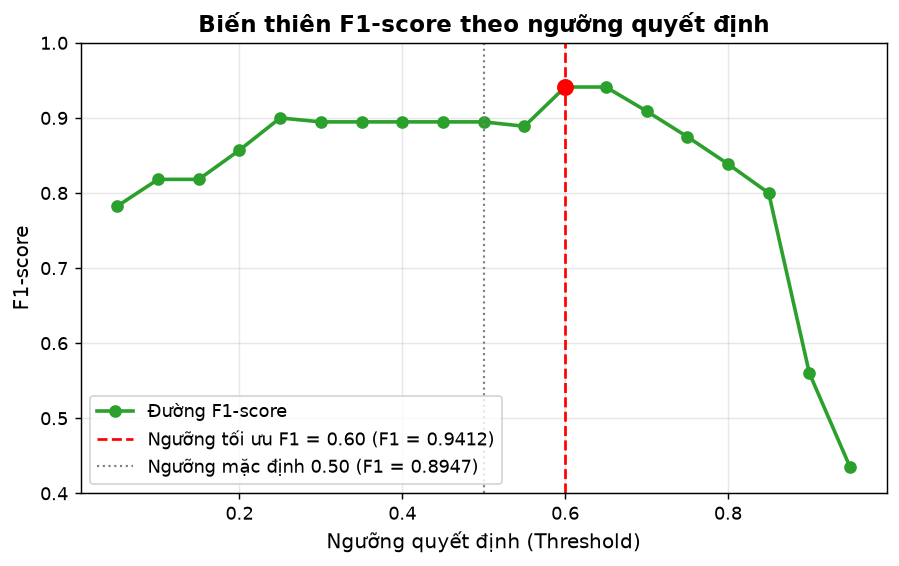

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

# 1. Đọc dữ liệu và chia tập train/test
df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

mo_hinh = LogisticRegression().fit(X_train, y_train)
p_test = mo_hinh.predict_proba(X_test)[:, 1]

# 2. Dò ngưỡng từ 0.05 đến 0.95 với bước nhảy 0.05
nguong_list = np.arange(0.05, 1.0, 0.05)
f1_list = []
best_f1 = -1.0
best_nguong = 0.5

print("BẢNG DÒ TÌM NGƯỠNG QUYẾT ĐỊNH THEO F1-SCORE:")
print("  Ngưỡng   Số đoán qua   Precision    Recall      F1-score")
print("  --------------------------------------------------------")

for nguong in nguong_list:
    y_pred_t = (p_test >= nguong).astype(int)
    pre = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    f1_list.append(f1)
    
    print(f"   {nguong:4.2f}        {y_pred_t.sum():2d}        {pre:6.4f}     {rec:6.4f}     {f1:6.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_nguong = nguong

print("  --------------------------------------------------------")
print(f"Ngưỡng cho F1 cao nhất là: {best_nguong:.2f} với F1 = {best_f1:.4f}")
print()
print("Nhận xét:")
print(f"Ngưỡng tốt nhất theo F1 là {best_nguong:.2f}, KHÔNG PHẢI bằng 0.5.")
print(f"- Tại ngưỡng mặc định 0.5: F1 đạt 0.8947 (Precision = 0.8500, Recall = 0.9444).")
print(f"- Khi nâng ngưỡng lên 0.60: Mô hình khắt khe hơn, loại bỏ được toàn bộ 3 ca FP (đoán nhầm qua môn),")
print(f"  giúp Precision tăng vọt lên 1.0000 trong khi Recall chỉ giảm nhẹ về 0.8889. Do đó, F1 đạt đỉnh 0.9412.")


---
## Bài tập 6: Đổi lớp dương rồi chấm lại
**Yêu cầu:**  
Ở mục 5 ta luôn lấy lớp dương là qua môn (lớp 1). Bây giờ hãy chấm điểm cho lớp rớt môn, tức lớp 0.  
*Gợi ý:* Thêm tham số `pos_label=0` vào `precision_score` và `recall_score`. In ra precision và recall của lớp 0 rồi so với con số của lớp 1 trong tài liệu. Giải thích bằng lời vì sao hai bộ số khác nhau, dù mô hình và dữ liệu không đổi chút nào.


BẢNG SO SÁNH CHỈ SỐ GIỮA HAI LỚP:
  Lớp 1 (Qua môn) : Precision = 0.8500 | Recall = 0.9444 | F1 = 0.8947
  Lớp 0 (Rớt môn) : Precision = 0.9000 | Recall = 0.7500 | F1 = 0.8182

Dữ liệu kiểm tra gồm 30 SV (Thực tế: 18 bạn Qua môn, 12 bạn Rớt môn):
  - Khi coi Lớp 1 (Qua môn) là dương:
    * Precision = TP / (TP + FP) = 17 / (17 + 3) = 0.8500
    * Recall    = TP / (TP + FN) = 17 / (17 + 1) = 0.9444

  - Khi coi Lớp 0 (Rớt môn) là dương:
    * Precision = TN / (TN + FN) = 9 / (9 + 1) = 0.9000
    * Recall    = TN / (TN + FP) = 9 / (9 + 3) = 0.7500

GIẢI THÍCH BẰNG LỜI VÌ SAO HAI BỘ SỐ KHÁC NHAU:
1. Bản chất của Precision và Recall phụ thuộc vào 'lớp dương' mà ta đang quan sát:
   - Precision trả lời: 'Trong số những ca mô hình gán nhãn dương, có bao nhiêu phần trăm đúng?'
   - Recall trả lời: 'Trong toàn bộ các ca dương tính có thật, mô hình tìm ra được bao nhiêu phần trăm?'

2. Khi đổi lớp dương từ Qua môn sang Rớt môn, vai trò các ô bị đảo ngược hoàn toàn:
   - Với Lớp 1 (Qua môn): Mô 

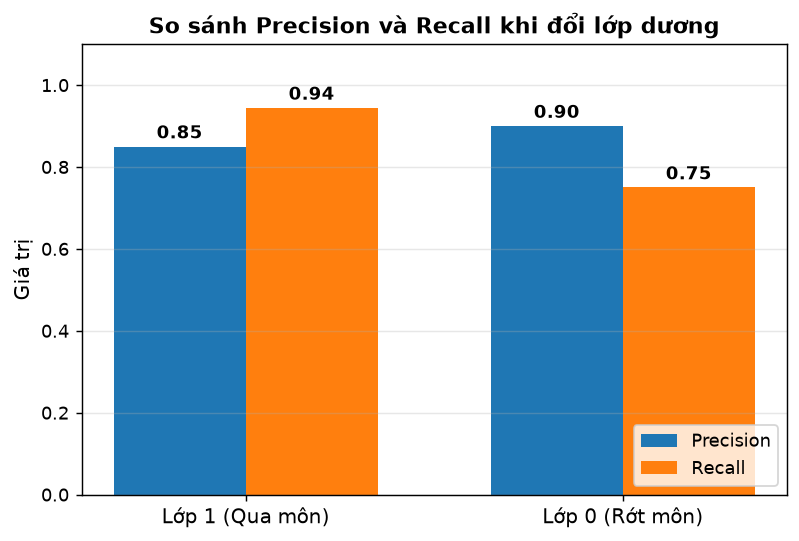

In [1]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# 1. Tính toán cho lớp 1 (Qua môn - mặc định pos_label=1)
pre_lop1 = precision_score(y_test, y_pred, pos_label=1)
rec_lop1 = recall_score(y_test, y_pred, pos_label=1)
f1_lop1 = f1_score(y_test, y_pred, pos_label=1)

# 2. Tính toán cho lớp 0 (Rớt môn - pos_label=0)
pre_lop0 = precision_score(y_test, y_pred, pos_label=0)
rec_lop0 = recall_score(y_test, y_pred, pos_label=0)
f1_lop0 = f1_score(y_test, y_pred, pos_label=0)

print("BẢNG SO SÁNH CHỈ SỐ GIỮA HAI LỚP:")
print(f"  Lớp 1 (Qua môn) : Precision = {pre_lop1:.4f} | Recall = {rec_lop1:.4f} | F1 = {f1_lop1:.4f}")
print(f"  Lớp 0 (Rớt môn) : Precision = {pre_lop0:.4f} | Recall = {rec_lop0:.4f} | F1 = {f1_lop0:.4f}")
print()

# Chi tiết đối chiếu
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"Dữ liệu kiểm tra gồm 30 SV (Thực tế: 18 bạn Qua môn, 12 bạn Rớt môn):")
print(f"  - Khi coi Lớp 1 (Qua môn) là dương:")
print(f"    * Precision = TP / (TP + FP) = {tp} / ({tp} + {fp}) = {pre_lop1:.4f}")
print(f"    * Recall    = TP / (TP + FN) = {tp} / ({tp} + {fn}) = {rec_lop1:.4f}")
print()
print(f"  - Khi coi Lớp 0 (Rớt môn) là dương:")
print(f"    * Precision = TN / (TN + FN) = {tn} / ({tn} + {fn}) = {pre_lop0:.4f}")
print(f"    * Recall    = TN / (TN + FP) = {tn} / ({tn} + {fp}) = {rec_lop0:.4f}")
print()

print("GIẢI THÍCH BẰNG LỜI VÌ SAO HAI BỘ SỐ KHÁC NHAU:")
print("1. Bản chất của Precision và Recall phụ thuộc vào 'lớp dương' mà ta đang quan sát:")
print("   - Precision trả lời: 'Trong số những ca mô hình gán nhãn dương, có bao nhiêu phần trăm đúng?'")
print("   - Recall trả lời: 'Trong toàn bộ các ca dương tính có thật, mô hình tìm ra được bao nhiêu phần trăm?'")
print()
print("2. Khi đổi lớp dương từ Qua môn sang Rớt môn, vai trò các ô bị đảo ngược hoàn toàn:")
print("   - Với Lớp 1 (Qua môn): Mô hình 'dễ dãi' đoán qua môn nhiều (20 bạn), bắt được 17/18 bạn qua thật => Recall rất cao (94.44%), nhưng Precision thấp hơn (85.00%) vì có 3 ca FP.")
print("   - Với Lớp 0 (Rớt môn): Mô hình 'khắt khe' khi đoán rớt (chỉ gán nhãn rớt cho 10 bạn), trong đó có 9 bạn rớt thật => Precision rất cao (90.00%). Nhưng trong tổng số 12 bạn rớt thật, nó bỏ sót 3 bạn => Recall chỉ đạt 75.00%.")
print()
print("3. Kết luận: Hai bộ số khác nhau là hoàn toàn tự nhiên và phản ánh chính xác hai góc nhìn nghiệp vụ khác nhau của cùng một mô hình.")
